In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("synthetic_customer_churn_100k.csv")
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [6]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [8]:
print(df.duplicated().sum())

0


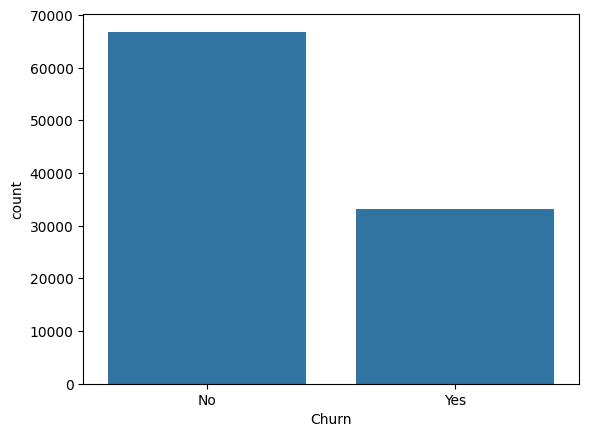

In [9]:
#EDA
sns.countplot(x = df["Churn"],data = df)
plt.show()

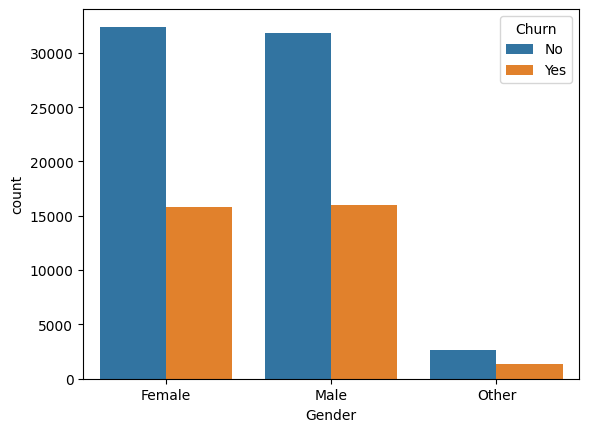

In [10]:
#now considering the gender
sns.countplot(x = df["Gender"],hue = df["Churn"],data = df)
plt.show()

In [11]:
#INSIGHTS:
# the churn rate is identical across gender that indicates gender is not a strong predictor of churn.

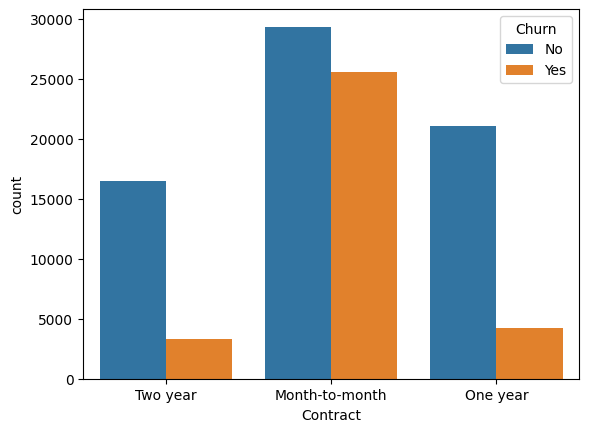

In [12]:
#now checking if contract type affect churn
sns.countplot(x = "Contract",hue = "Churn",data = df)
plt.show()

In [13]:
#INSIGHT:
# 1) Month-to-month customers churn more.
# 2) Indicates low commitment.
# 3) Suggest offering long-term discounts.

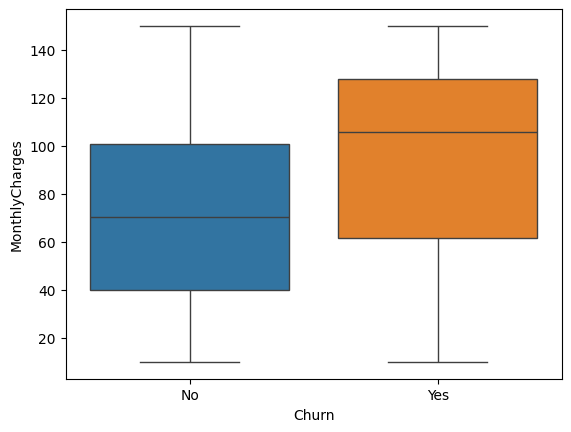

In [14]:
#now checking the if the monthly charges plays any role in the customer churns
sns.boxplot(x = "Churn", y = "MonthlyCharges",hue = "Churn",data = df)
plt.show()

In [15]:
#INSIGHTS
# 1) Higher charges leads to the higher churns.
# 2) Customers are price sensitive.
# 3) Suggest better pricing strategies.

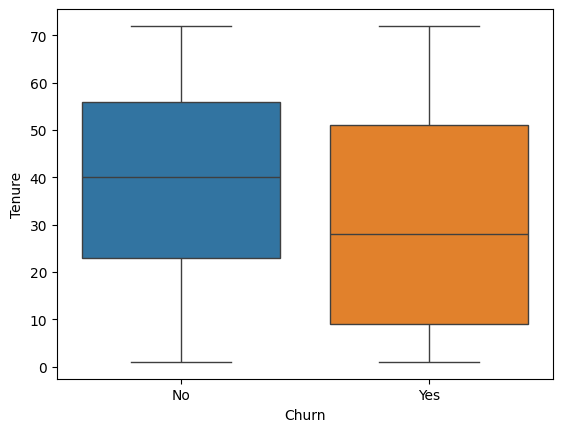

In [16]:
#now considering the tenure and checking if it plays any role in customer churn
sns.boxplot(x = "Churn",y = "Tenure",hue = "Churn",data = df)
plt.show()

In [17]:
#INSIGHTS:
# 1) New Customers(low tenure) churn more frequently than long-term customers.
# 2) Company should focus on onboarding experience and first 3 months retention strategy.

In [18]:
#Now performing the feature engineering
df["AvgMonthlySpend"] = df["TotalCharges"]/df["Tenure"].replace(0,1)

In [19]:
#from the above, we got to know that if the customer spends more but has a low tenure then it means it is a risky customer otherwise it is a loyal customer.

In [20]:
#now grouping the customers in the different groups based on their tenure
def tenure_group(x):
    if x<=12:
        return "New"
    elif x <= 36:
        return "Mid-term"
    else:
        return "Long-term"
df["Tenure_Group"] = df["Tenure"].apply(tenure_group)

In [21]:
#Creating a new column to look if the customer is on a long term contract or not
def Contract_check(x):
    if x != "Month-to-month":
        return 1
    else:
        return 0
df["Is_a_Long_Contract"] = df["Contract"].apply(Contract_check)

In [22]:
#now Creating a column to check if the payment of the customers is high or not
df["High_Charges"] = df["MonthlyCharges"].apply(lambda x:1 if x>=70 else 0)
#Expensive plans often lead to churn

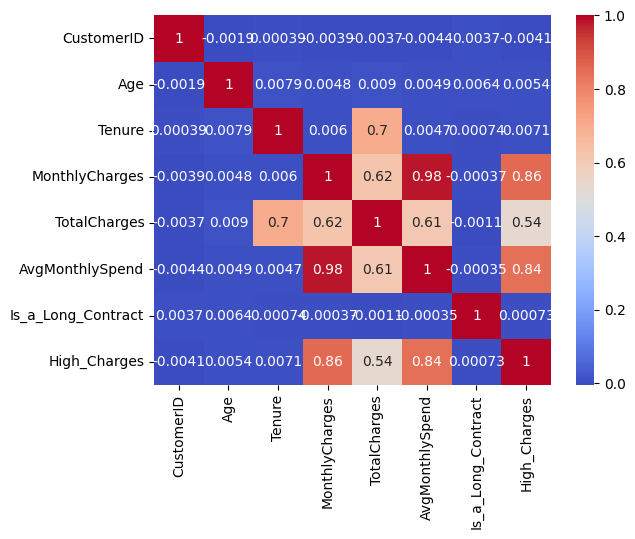

In [23]:
correlation = df.corr(numeric_only = True)
sns.heatmap(correlation, annot = True, cmap = "coolwarm")
plt.show()
df.to_csv("customer_churn_cleaned.csv")

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,precision_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer

In [25]:
x = df.drop("Churn",axis = 1)
y = df["Churn"]

In [26]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [27]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
num_cols = ["Age","Tenure","MonthlyCharges","TotalCharges","AvgMonthlySpend","Is_a_Long_Contract","High_Charges"]
cat_cols = ["Gender","Contract","PaymentMethod","Tenure_Group"]
num_cols_pipeline = Pipeline([("scaler",StandardScaler())])
cat_cols_pipeline = Pipeline([("ohe",OneHotEncoder(handle_unknown = "ignore",sparse_output = False))])

In [28]:
preprocessor = ColumnTransformer([
    ("num",num_cols_pipeline,num_cols),
    ("cat",cat_cols_pipeline,cat_cols)
])
#logistic Regression
lr_model = Pipeline([
    ("pre",preprocessor),
    ("lr",LogisticRegression(max_iter = 1000))
])
lr_model.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spars

In [29]:
y_pred_lr = lr_model.predict(xtest)
print("Logistic Regression Accuracy : ",accuracy_score(ytest,y_pred_lr))

Logistic Regression Accuracy :  0.75305


In [30]:
print("Classification Report (Linear Regression) : ")
print(classification_report(ytest,y_pred_lr))

Classification Report (Linear Regression) : 
              precision    recall  f1-score   support

          No       0.78      0.87      0.82     13294
         Yes       0.67      0.51      0.58      6706

    accuracy                           0.75     20000
   macro avg       0.73      0.69      0.70     20000
weighted avg       0.74      0.75      0.74     20000



In [31]:
dt_model = Pipeline([
    ("pre",preprocessor),
    ("dt",DecisionTreeClassifier())
])
dt_model.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('dt', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spars

In [32]:
y_pred_dt = dt_model.predict(xtest)
print("Decision Tree Accuracy : ",accuracy_score(ytest,y_pred_dt))

Decision Tree Accuracy :  0.68095


In [33]:
print("Classification Report (Decision Tree) : ")
print(classification_report(ytest,y_pred_dt))

Classification Report (Decision Tree) : 
              precision    recall  f1-score   support

          No       0.76      0.76      0.76     13294
         Yes       0.52      0.53      0.53      6706

    accuracy                           0.68     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.68      0.68      0.68     20000



In [34]:
rf_model = Pipeline([
    ("pre",preprocessor),
    ("rf",RandomForestClassifier())
])
rf_model.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spars

In [35]:
y_pred_rf = rf_model.predict(xtest)
print("Random Forest Accuracy : ",accuracy_score(ytest,y_pred_rf))

Random Forest Accuracy :  0.73275


In [36]:
print("Classification Report (Random Forest) : ")
print(classification_report(ytest,y_pred_rf))

Classification Report (Random Forest) : 
              precision    recall  f1-score   support

          No       0.77      0.85      0.81     13294
         Yes       0.62      0.51      0.56      6706

    accuracy                           0.73     20000
   macro avg       0.70      0.68      0.68     20000
weighted avg       0.72      0.73      0.73     20000



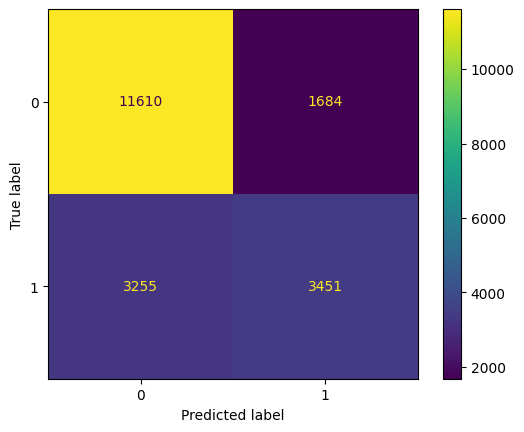

In [37]:
cm = confusion_matrix(ytest,y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

In [41]:
import joblib
joblib.dump(lr_model,"lr_model.pkl")

['lr_model.pkl']

In [42]:
code = """
import streamlit as st
import pickle
import pandas as pd
import numpy as np
import joblib
model = joblib.load("lr_model.pkl")
st.sidebar.title("Customer Info")
st.sidebar.subheader("Personal Info")
st.title("Customer Churn Prediction App")
st.write("Enter customer details below : ")
Tenure = st.sidebar.slider("Tenure (Months) ",0,72)
st.sidebar.subheader("Billing Info")
MonthlyCharges = st.sidebar.number_input("Monthly Charges")
AvgMonthlySpend = st.sidebar.number_input("AvgMonthlySpend")
TotalCharges = st.sidebar.number_input("Total Charges")
Age = st.number_input("Age")
Gender = st.selectbox("Gender",["Male","Female"])
Contract = st.selectbox("Contract Type",["Month-to-month","One year","Two year"])
PaymentMethod = st.selectbox("Payment methods",["Bank transfer","Mailed check","Electronic check","Credit card"])
Tenure_Group = st.selectbox("Tenure Group",["Long-term","Mid-term","New"])
Is_a_Long_Contract = st.selectbox("Long Contract",["Yes","No"])
High_Charges = st.selectbox("High Charges",["Yes","No"])

Age = float(Age)
Tenure = float(Tenure)
MonthlyCharges = float(MonthlyCharges)
TotalCharges = float(TotalCharges)
AvgMonthlySpend = float(AvgMonthlySpend)
Is_a_Long_Contract = 1 if Is_a_Long_Contract == "Yes" else 0
High_Charges = 1 if High_Charges == "Yes" else 0

if st.button("Predict"):
    features = pd.DataFrame(
    [[
        Age,
        Tenure,
        MonthlyCharges,
        TotalCharges,
        AvgMonthlySpend,
        Is_a_Long_Contract,
        High_Charges,
        Gender,
        Contract,
        PaymentMethod,
        Tenure_Group
    ]],
    
    columns = [
        "Age","Tenure","MonthlyCharges","TotalCharges","AvgMonthlySpend",
        "Is_a_Long_Contract","High_Charges",
        "Gender","Contract","PaymentMethod","Tenure_Group"
    ]
)
    prediction = model.predict(features)
    if prediction[0] == 1:
        st.error("Customer is likely to Churn")
    else:
        st.success("Customer is likely to Stay")
"""
with open("Customer_Churn_app.py","w") as f:
    f.write(code)

In [43]:
import os
os.getcwd()

'C:\\Users\\ABC\\Desktop\\jupyter notebook\\Customer Churn Prediction Project'